<a href="https://colab.research.google.com/github/msolowes-star/DI-Bootcamp/blob/main/Week4Day6ExerciseXP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [98]:
from google.colab import files

uploaded = files.upload()

Saving titanic dataset.zip to titanic dataset (8).zip


In [99]:
# Cell 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder

In [100]:
import zipfile

with zipfile.ZipFile("titanic dataset.zip", "r") as zip_ref:
    zip_ref.extractall()

In [101]:
import os

print(os.listdir())

['.config', 'titanic dataset (4).zip', 'titanic dataset.zip', 'titanic dataset (7).zip', 'titanic dataset (8).zip', 'titanic dataset (3).zip', 'titanic dataset', 'titanic dataset (1).zip', 'titanic dataset (2).zip', 'titanic dataset (6).zip', 'titanic dataset (5).zip', 'sample_data']


In [102]:
import zipfile

with zipfile.ZipFile("titanic dataset.zip", "r") as zip_ref:
    zip_ref.extractall()

In [103]:
import os

for root, dirs, files in os.walk("."):
    for file in files:
        print(os.path.join(root, file))

./titanic dataset (4).zip
./titanic dataset.zip
./titanic dataset (7).zip
./titanic dataset (8).zip
./titanic dataset (3).zip
./titanic dataset (1).zip
./titanic dataset (2).zip
./titanic dataset (6).zip
./titanic dataset (5).zip
./.config/config_sentinel
./.config/active_config
./.config/gce
./.config/.last_opt_in_prompt.yaml
./.config/default_configs.db
./.config/.last_survey_prompt.yaml
./.config/.last_update_check.json
./.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db
./.config/logs/2026.06.04/13.32.21.210570.log
./.config/logs/2026.06.04/13.32.39.344962.log
./.config/logs/2026.06.04/13.31.42.499627.log
./.config/logs/2026.06.04/13.32.18.735754.log
./.config/logs/2026.06.04/13.32.38.346437.log
./.config/logs/2026.06.04/13.32.02.654775.log
./.config/configurations/config_default
./titanic dataset/test.csv
./titanic dataset/train.csv
./titanic dataset/gender_submission.csv
./sample_data/README.md
./sample_data/anscombe.json
./sample_data/mnist_test.csv
./sample

In [104]:
# Cell 2: Load the dataset
df = pd.read_csv("titanic dataset/train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [105]:
# Cell 3: Explore the dataset
print("Dataset shape:", df.shape)

df.info()

df.describe(include="all")

Dataset shape: (891, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


EXERCISE 1

In [106]:
rows_before = df.shape[0]
print("Rows before:", rows_before)

Rows before: 891


In [107]:
rows_before = df.shape[0]
print("Rows before:", rows_before)

Rows before: 891


In [108]:
duplicates = df.duplicated().sum()

print("Duplicate rows:", duplicates)

Duplicate rows: 0


In [109]:
df = df.drop_duplicates()

In [110]:
rows_after = df.shape[0]

print("Rows after:", rows_after)
print("Duplicates remaining:", df.duplicated().sum())

Rows after: 891
Duplicates remaining: 0


The Titanic dataset contains few (or no) duplicate rows, but checking for duplicates is an important first preprocessing step because duplicates can bias machine learning models.

EXERCISE 2

In [111]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


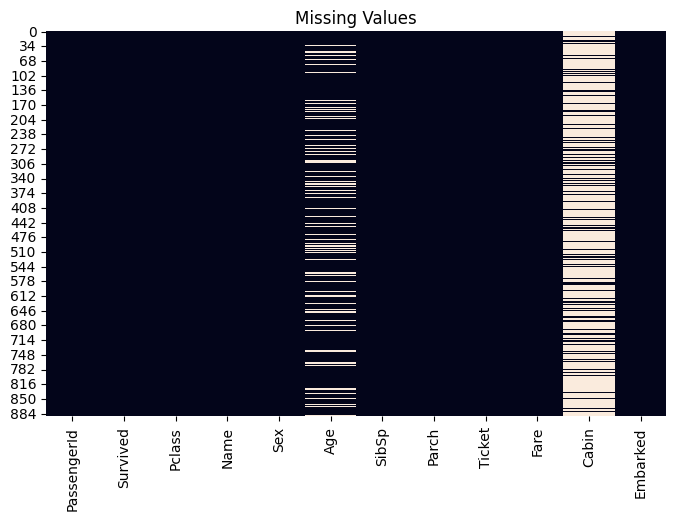

In [112]:
plt.figure(figsize=(8,5))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values")
plt.show()

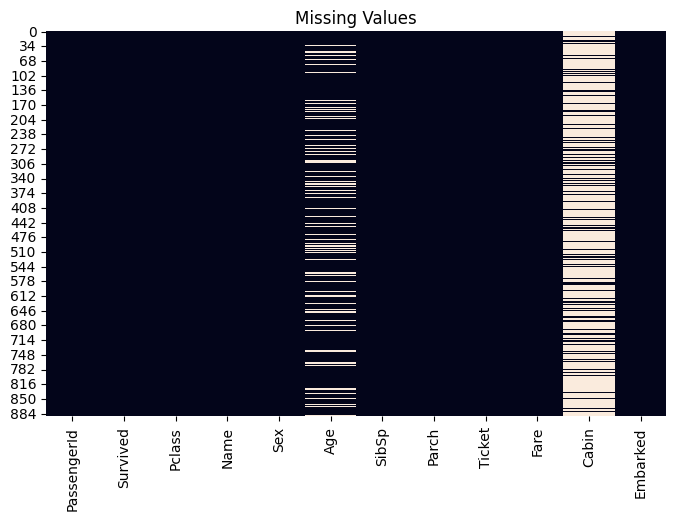

In [113]:
plt.figure(figsize=(8,5))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values")
plt.show()

In [114]:
age_imputer = SimpleImputer(strategy="median")

df["Age"] = age_imputer.fit_transform(df[["Age"]])

In [115]:
embarked_imputer = SimpleImputer(strategy="most_frequent")

df["Embarked"] = embarked_imputer.fit_transform(df[["Embarked"]]).ravel()

In [116]:
df = df.drop(columns=["Cabin"])

In [117]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


EXERCISE 3

In [118]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [119]:
df["Title"] = df["Name"].str.extract(" ([A-Za-z]+)\.", expand=False)

df["Title"].value_counts()

<>:1: SyntaxWarning: invalid escape sequence '\.'
<>:1: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_1850/1062959381.py:1: SyntaxWarning: invalid escape sequence '\.'
  df["Title"] = df["Name"].str.extract(" ([A-Za-z]+)\.", expand=False)


,count
Title,
Mr,517
Miss,182
Mrs,125
Master,40
Dr,7
Rev,6
Col,2
Mlle,2
Major,2


In [120]:
df["Title"] = df["Title"].replace(
    ["Lady","Countess","Capt","Col","Don","Dr","Major",
     "Rev","Sir","Jonkheer","Dona"],
    "Rare"
)

df["Title"] = df["Title"].replace("Mlle","Miss")
df["Title"] = df["Title"].replace("Ms","Miss")
df["Title"] = df["Title"].replace("Mme","Mrs")

In [121]:
title_encoder = LabelEncoder()

df["Title"] = title_encoder.fit_transform(df["Title"])

EXERCISE 4

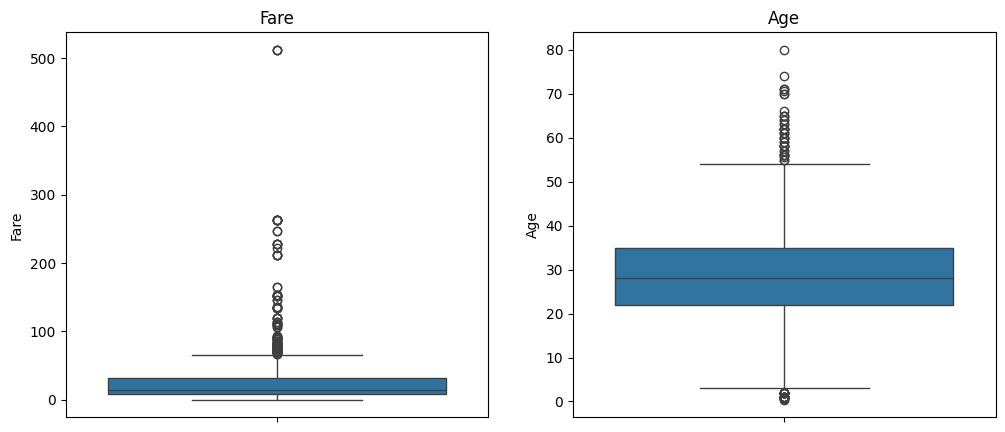

In [122]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(y=df["Fare"])
plt.title("Fare")

plt.subplot(1,2,2)
sns.boxplot(y=df["Age"])
plt.title("Age")

plt.show()

In [123]:
Q1 = df["Fare"].quantile(0.25)
Q3 = df["Fare"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

print(lower)
print(upper)

-26.724
65.6344


In [124]:
cap = df["Fare"].quantile(0.98)

df["Fare"] = np.where(df["Fare"] > cap,
                      cap,
                      df["Fare"])

In [125]:
df["Fare"] = np.log1p(df["Fare"])

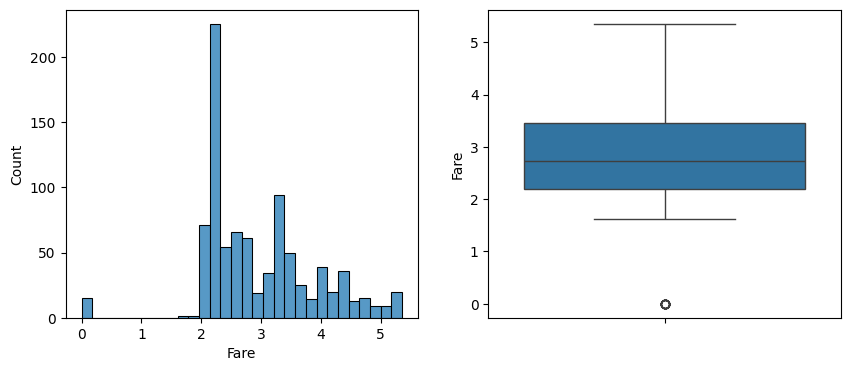

In [126]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(df["Fare"], bins=30)

plt.subplot(1,2,2)
sns.boxplot(y=df["Fare"])

plt.show()

EXERCISE 5

In [127]:
# Create FamilySize by combining siblings/spouses, parents/children,
# and the passenger themself
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

# Verify the new column
df[["SibSp", "Parch", "FamilySize"]].head()

,SibSp,Parch,FamilySize
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


In [128]:
numerical = ["Age","Fare","SibSp","Parch","FamilySize"]

In [129]:
standard = StandardScaler()

df[["Age","FamilySize"]] = standard.fit_transform(
    df[["Age","FamilySize"]]
)

In [130]:
minmax = MinMaxScaler()

df[["Fare","SibSp","Parch"]] = minmax.fit_transform(
    df[["Fare","SibSp","Parch"]]
)

EXERCISE 6

In [131]:
df.select_dtypes(include="object").columns

Index(['Name', 'Sex', 'Ticket', 'Embarked'], dtype='object')

In [132]:
df = pd.get_dummies(
    df,
    columns=["Sex","Embarked"],
    drop_first=True
)

In [133]:
df.head()

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Title,FamilySize,Sex_male,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",-0.565736,0.125,0.0,A/5 21171,0.393830,2,0.059160,True,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0.663861,0.125,0.0,PC 17599,0.798890,3,0.059160,False,False,False
2,3,1,3,"Heikkinen, Miss. Laina",-0.258337,0.000,0.0,STON/O2. 3101282,0.408508,1,-0.560975,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0.433312,0.125,0.0,113803,0.744812,3,0.059160,False,False,True
4,5,0,3,"Allen, Mr. William Henry",0.433312,0.000,0.0,373450,0.411103,2,-0.560975,True,False,True


EXERCISE 7

In [134]:
bins = [0,12,18,60,100]

labels = ["Child","Teen","Adult","Senior"]

df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [135]:
age_dummies = pd.get_dummies(
    df["AgeGroup"],
    prefix="Age"
)

df = pd.concat([df, age_dummies], axis=1)

df.drop(columns=["AgeGroup"], inplace=True)

In [136]:
df.head()

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Title,FamilySize,Sex_male,Embarked_Q,Embarked_S,Age_Child,Age_Teen,Age_Adult,Age_Senior
0,1,0,3,"Braund, Mr. Owen Harris",-0.565736,0.125,0.0,A/5 21171,0.393830,2,0.059160,True,False,True,False,False,False,False
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0.663861,0.125,0.0,PC 17599,0.798890,3,0.059160,False,False,False,True,False,False,False
2,3,1,3,"Heikkinen, Miss. Laina",-0.258337,0.000,0.0,STON/O2. 3101282,0.408508,1,-0.560975,False,False,True,False,False,False,False
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0.433312,0.125,0.0,113803,0.744812,3,0.059160,False,False,True,True,False,False,False
4,5,0,3,"Allen, Mr. William Henry",0.433312,0.000,0.0,373450,0.411103,2,-0.560975,True,False,True,True,False,False,False


In [137]:
print(df.info())

print(df.isnull().sum())

print(df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Age          891 non-null    float64
 5   SibSp        891 non-null    float64
 6   Parch        891 non-null    float64
 7   Ticket       891 non-null    object 
 8   Fare         891 non-null    float64
 9   Title        891 non-null    int64  
 10  FamilySize   891 non-null    float64
 11  Sex_male     891 non-null    bool   
 12  Embarked_Q   891 non-null    bool   
 13  Embarked_S   891 non-null    bool   
 14  Age_Child    891 non-null    bool   
 15  Age_Teen     891 non-null    bool   
 16  Age_Adult    891 non-null    bool   
 17  Age_Senior   891 non-null    bool   
dtypes: bool(7), float64(5), int64(4), object(2)
memory